# Credit Scoring Model

### CodeAlpha Machine Learning Internship — Task 1

**Objective:** Predict an individual's creditworthiness using historical financial data and machine learning classification algorithms.

**Algorithms Used:**
- Logistic Regression
- Random Forest

**Evaluation Metrics:**
- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC

## Objective

The objective of this project is to develop a machine learning model that predicts an individual's creditworthiness using historical financial data.

The project uses classification algorithms to classify applicants into two categories:

- Good Credit
- Bad Credit

### Machine Learning Algorithms

- Logistic Regression
- Random Forest

### Evaluation Metrics

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

print("Libraries imported successfully!")


Libraries imported successfully!


In [2]:
# Step 4: Load the German Credit Dataset

import pandas as pd

# UCI German Credit dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"

# Column names
columns = [
    "checking_account",
    "duration",
    "credit_history",
    "purpose",
    "credit_amount",
    "savings_account",
    "employment",
    "installment_rate",
    "personal_status",
    "other_debtors",
    "residence",
    "property",
    "age",
    "other_installments",
    "housing",
    "existing_credits",
    "job",
    "people_liable",
    "telephone",
    "foreign_worker",
    "credit_risk"
]

# Load dataset
df = pd.read_csv(
    url,
    sep=" ",
    header=None,
    names=columns
)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

# Display first 5 rows
df.head()

Dataset loaded successfully!
Shape: (1000, 21)


,checking_account,duration,credit_history,purpose,credit_amount,savings_account,employment,installment_rate,personal_status,other_debtors,...,property,age,other_installments,housing,existing_credits,job,people_liable,telephone,foreign_worker,credit_risk
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [3]:
# Step 5: Understand the Dataset

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

Number of rows: 1000
Number of columns: 21

Column names:
['checking_account', 'duration', 'credit_history', 'purpose', 'credit_amount', 'savings_account', 'employment', 'installment_rate', 'personal_status', 'other_debtors', 'residence', 'property', 'age', 'other_installments', 'housing', 'existing_credits', 'job', 'people_liable', 'telephone', 'foreign_worker', 'credit_risk']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   checking_account    1000 non-null   object
 1   duration            1000 non-null   int64 
 2   credit_history      1000 non-null   object
 3   purpose             1000 non-null   object
 4   credit_amount       1000 non-null   int64 
 5   savings_account     1000 non-null   object
 6   employment          1000 non-null   object
 7   installment_rate    1000 non-null   int64 
 8   person

In [4]:
# Step 6: Check Missing Values

print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
checking_account      0
duration              0
credit_history        0
purpose               0
credit_amount         0
savings_account       0
employment            0
installment_rate      0
personal_status       0
other_debtors         0
residence             0
property              0
age                   0
other_installments    0
housing               0
existing_credits      0
job                   0
people_liable         0
telephone             0
foreign_worker        0
credit_risk           0
dtype: int64


In [6]:
# Step 7: Check Credit Risk Distribution

print(df["credit_risk"].value_counts())

print("\nPercentage distribution:")
print(df["credit_risk"].value_counts(normalize=True) * 100)

credit_risk
1    700
2    300
Name: count, dtype: int64

Percentage distribution:
credit_risk
1    70.0
2    30.0
Name: proportion, dtype: float64


In [7]:
# Step 8: Convert Target Variable

df["credit_risk"] = df["credit_risk"].map({
    1: 0,
    2: 1
})

print(df["credit_risk"].value_counts())

print("\n0 = Good Credit")
print("1 = Bad Credit")

credit_risk
0    700
1    300
Name: count, dtype: int64

0 = Good Credit
1 = Bad Credit


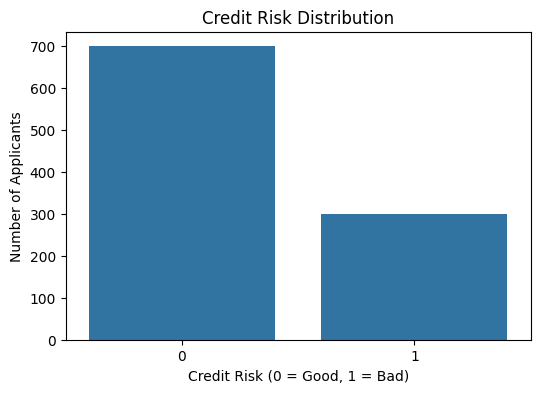

In [8]:
# Step 9: Credit Risk Distribution

plt.figure(figsize=(6, 4))

sns.countplot(x="credit_risk", data=df)

plt.title("Credit Risk Distribution")
plt.xlabel("Credit Risk (0 = Good, 1 = Bad)")
plt.ylabel("Number of Applicants")

plt.show()

In [9]:
# Step 10: Statistical Summary

df.describe()

,duration,credit_amount,installment_rate,residence,age,existing_credits,people_liable,credit_risk
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000,0.300000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086,0.458487
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000,0.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000,0.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000,0.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000,1.000000


In [10]:
# Step 11: Separate Features and Target

X = df.drop("credit_risk", axis=1)
y = df["credit_risk"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features shape: (1000, 20)
Target shape: (1000,)

Features:
['checking_account', 'duration', 'credit_history', 'purpose', 'credit_amount', 'savings_account', 'employment', 'installment_rate', 'personal_status', 'other_debtors', 'residence', 'property', 'age', 'other_installments', 'housing', 'existing_credits', 'job', 'people_liable', 'telephone', 'foreign_worker']

Target:
credit_risk


In [11]:
# Step 12: Identify Numerical and Categorical Columns

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

print("\nNumber of Numerical Features:", len(numerical_features))
print("Number of Categorical Features:", len(categorical_features))

Numerical Features:
['duration', 'credit_amount', 'installment_rate', 'residence', 'age', 'existing_credits', 'people_liable']

Categorical Features:
['checking_account', 'credit_history', 'purpose', 'savings_account', 'employment', 'personal_status', 'other_debtors', 'property', 'other_installments', 'housing', 'job', 'telephone', 'foreign_worker']

Number of Numerical Features: 7
Number of Categorical Features: 13


In [12]:
# Step 13: Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training data: (800, 20)
Testing data: (200, 20)

Training target distribution:
credit_risk
0    560
1    240
Name: count, dtype: int64

Testing target distribution:
credit_risk
0    140
1     60
Name: count, dtype: int64


In [13]:
# Step 14: Create Preprocessing Pipeline

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [14]:
# Step 15: Test Preprocessing

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training data shape:", X_train_processed.shape)
print("Processed testing data shape:", X_test_processed.shape)

Processed training data shape: (800, 61)
Processed testing data shape: (200, 61)


In [15]:
# Step 16: Logistic Regression Model

from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_processed, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [16]:
# Step 17: Logistic Regression Predictions

y_pred_lr = logistic_model.predict(X_test_processed)
y_prob_lr = logistic_model.predict_proba(X_test_processed)[:, 1]

print("Predictions completed!")
print("\nFirst 10 predictions:")
print(y_pred_lr[:10])

Predictions completed!

First 10 predictions:
[0 0 1 0 0 0 0 0 0 0]


In [17]:
# Step 18: Evaluate Logistic Regression

accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
roc_auc_lr = roc_auc_score(y_test, y_prob_lr)

print("Logistic Regression Results")
print("--------------------------------")
print("Accuracy :", round(accuracy_lr, 4))
print("Precision:", round(precision_lr, 4))
print("Recall   :", round(recall_lr, 4))
print("F1-Score :", round(f1_lr, 4))
print("ROC-AUC  :", round(roc_auc_lr, 4))

Logistic Regression Results
--------------------------------
Accuracy : 0.78
Precision: 0.6667
Recall   : 0.5333
F1-Score : 0.5926
ROC-AUC  : 0.804


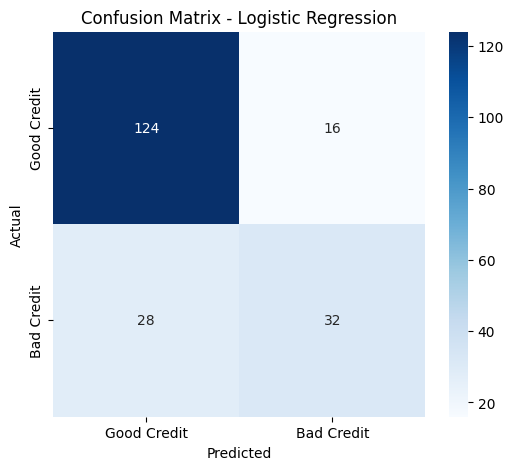

In [18]:
# Step 19: Confusion Matrix

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Good Credit", "Bad Credit"],
    yticklabels=["Good Credit", "Bad Credit"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [19]:
# Step 20: Random Forest Model

from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

random_forest_model.fit(X_train_processed, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [20]:
# Step 21: Random Forest Predictions

y_pred_rf = random_forest_model.predict(X_test_processed)

y_prob_rf = random_forest_model.predict_proba(
    X_test_processed
)[:, 1]

print("Random Forest predictions completed!")

print("\nFirst 10 predictions:")
print(y_pred_rf[:10])

Random Forest predictions completed!

First 10 predictions:
[0 0 1 1 0 0 0 0 0 0]


In [21]:
# Step 22: Evaluate Random Forest

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Results")
print("--------------------------------")
print("Accuracy :", round(accuracy_rf, 4))
print("Precision:", round(precision_rf, 4))
print("Recall   :", round(recall_rf, 4))
print("F1-Score :", round(f1_rf, 4))
print("ROC-AUC  :", round(roc_auc_rf, 4))

Random Forest Results
--------------------------------
Accuracy : 0.76
Precision: 0.6765
Recall   : 0.3833
F1-Score : 0.4894
ROC-AUC  : 0.7949


In [22]:
# Step 23: Compare Models

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_lr,
        accuracy_rf
    ],
    "Precision": [
        precision_lr,
        precision_rf
    ],
    "Recall": [
        recall_lr,
        recall_rf
    ],
    "F1-Score": [
        f1_lr,
        f1_rf
    ],
    "ROC-AUC": [
        roc_auc_lr,
        roc_auc_rf
    ]
})

print(results.round(4))

                 Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
0  Logistic Regression      0.78     0.6667  0.5333    0.5926   0.8040
1        Random Forest      0.76     0.6765  0.3833    0.4894   0.7949


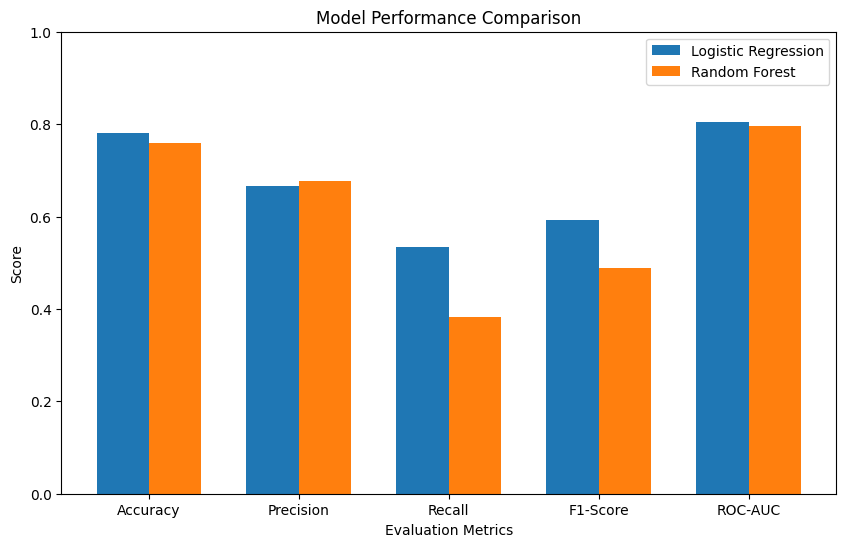

In [23]:
# Step 24: Model Performance Comparison

metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]

logistic_scores = [
    accuracy_lr,
    precision_lr,
    recall_lr,
    f1_lr,
    roc_auc_lr
]

random_forest_scores = [
    accuracy_rf,
    precision_rf,
    recall_rf,
    f1_rf,
    roc_auc_rf
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width/2,
    logistic_scores,
    width,
    label="Logistic Regression"
)

plt.bar(
    x + width/2,
    random_forest_scores,
    width,
    label="Random Forest"
)

plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")
plt.title("Model Performance Comparison")

plt.xticks(x, metrics)
plt.ylim(0, 1)

plt.legend()
plt.show()

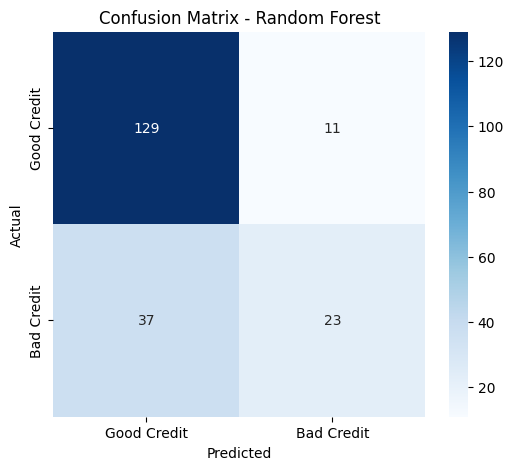

In [24]:
# Step 25: Random Forest Confusion Matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Good Credit", "Bad Credit"],
    yticklabels=["Good Credit", "Bad Credit"]
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

<Figure size 800x600 with 0 Axes>

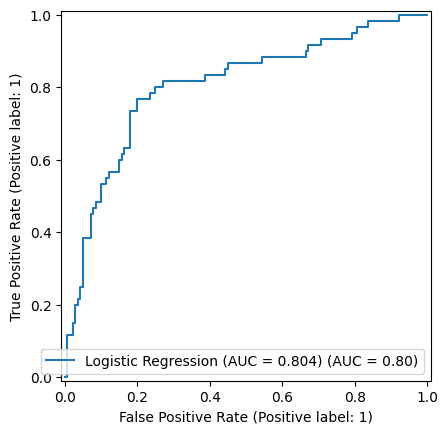

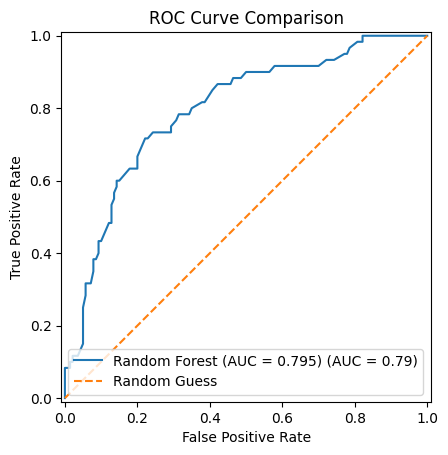

In [25]:
# Step 26: ROC Curve Comparison

plt.figure(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_lr,
    name=f"Logistic Regression (AUC = {roc_auc_lr:.3f})"
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf,
    name=f"Random Forest (AUC = {roc_auc_rf:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Guess"
)

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

In [26]:
# Step 27: Feature Importance

feature_names = preprocessor.get_feature_names_out()

importance = random_forest_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Top 15 Important Features:")
print(feature_importance.head(15))

Top 15 Important Features:
                         Feature  Importance
1             num__credit_amount    0.092686
0                  num__duration    0.079137
4                       num__age    0.073554
10     cat__checking_account_A14    0.064940
2          num__installment_rate    0.035913
7      cat__checking_account_A11    0.031730
3                 num__residence    0.030890
15       cat__credit_history_A34    0.025808
26      cat__savings_account_A61    0.022538
8      cat__checking_account_A12    0.019638
32           cat__employment_A72    0.017645
38      cat__personal_status_A93    0.017621
49  cat__other_installments_A143    0.017525
43            cat__property_A121    0.017435
5          num__existing_credits    0.017252


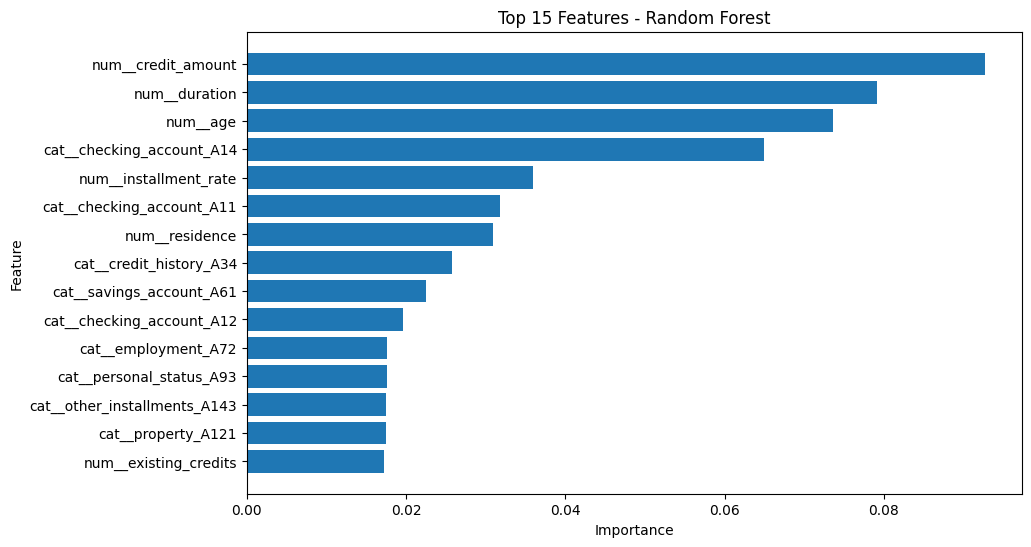

In [27]:
# Plot Top 15 Important Features

top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features - Random Forest")

plt.show()

In [28]:
# Step 28: Classification Report

print("Classification Report - Logistic Regression")
print("---------------------------------------------")

print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=["Good Credit", "Bad Credit"]
    )
)

Classification Report - Logistic Regression
---------------------------------------------
              precision    recall  f1-score   support

 Good Credit       0.82      0.89      0.85       140
  Bad Credit       0.67      0.53      0.59        60

    accuracy                           0.78       200
   macro avg       0.74      0.71      0.72       200
weighted avg       0.77      0.78      0.77       200



In [29]:
# Step 29: Predict Credit Risk for a New Applicant

# Create a new applicant
new_applicant = pd.DataFrame([{
    "checking_account": "A11",
    "duration": 12,
    "credit_history": "A32",
    "purpose": "A43",
    "credit_amount": 2500,
    "savings_account": "A61",
    "employment": "A73",
    "installment_rate": 2,
    "personal_status": "A93",
    "other_debtors": "A101",
    "residence": 4,
    "property": "A121",
    "age": 30,
    "other_installments": "A143",
    "housing": "A152",
    "existing_credits": 1,
    "job": "A173",
    "people_liable": 1,
    "telephone": "A192",
    "foreign_worker": "A201"
}])

# Apply the same preprocessing
new_applicant_processed = preprocessor.transform(new_applicant)

# Make prediction
prediction = logistic_model.predict(new_applicant_processed)[0]

# Get probability
probability = logistic_model.predict_proba(
    new_applicant_processed
)[0]

print("Credit Risk Prediction")
print("----------------------")

if prediction == 0:
    print("Prediction: GOOD CREDIT")
else:
    print("Prediction: BAD CREDIT")

print("\nProbability of Good Credit:", round(probability[0] * 100, 2), "%")
print("Probability of Bad Credit :", round(probability[1] * 100, 2), "%")

Credit Risk Prediction
----------------------
Prediction: GOOD CREDIT

Probability of Good Credit: 84.76 %
Probability of Bad Credit : 15.24 %


In [30]:
# Step 30: Final Model Results

final_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Logistic Regression": [
        accuracy_lr,
        precision_lr,
        recall_lr,
        f1_lr,
        roc_auc_lr
    ],
    "Random Forest": [
        accuracy_rf,
        precision_rf,
        recall_rf,
        f1_rf,
        roc_auc_rf
    ]
})

final_results["Logistic Regression"] = (
    final_results["Logistic Regression"].round(4)
)

final_results["Random Forest"] = (
    final_results["Random Forest"].round(4)
)

final_results

,Metric,Logistic Regression,Random Forest
0,Accuracy,0.7800,0.7600
1,Precision,0.6667,0.6765
2,Recall,0.5333,0.3833
3,F1-Score,0.5926,0.4894
4,ROC-AUC,0.8040,0.7949


## Final Results

The two machine learning models were evaluated using Accuracy, Precision, Recall, F1-Score, and ROC-AUC.

| Metric | Logistic Regression | Random Forest |
|---|---:|---:|
| Accuracy | 78.00% | 76.00% |
| Precision | 66.67% | 67.65% |
| Recall | 53.33% | 38.33% |
| F1-Score | 59.26% | 48.94% |
| ROC-AUC | 80.40% | 79.49% |

### Best Performing Model

Based on the evaluation results, Logistic Regression performed better overall on the test dataset.

The Logistic Regression model achieved:

- **Accuracy:** 78.00%
- **Precision:** 66.67%
- **Recall:** 53.33%
- **F1-Score:** 59.26%
- **ROC-AUC:** 80.40%

Therefore, Logistic Regression was selected as the final model for this project.

## Conclusion

A Credit Scoring Model was successfully developed using the German Credit dataset.

The data was preprocessed by handling numerical and categorical features using standardization and one-hot encoding. Two classification algorithms, Logistic Regression and Random Forest, were trained and evaluated.

Logistic Regression achieved an accuracy of 78.00% and an ROC-AUC score of 80.40%. Based on the overall evaluation metrics, Logistic Regression performed better than Random Forest on the test dataset.

This project demonstrates how machine learning classification techniques can be used to predict credit risk from historical financial information.